# Exploratory Analysis

## Goal 

This notebook breaks down the contents of our [disease prediction dataset](https://www.kaggle.com/datasets/kaushil268/disease-prediction-using-machine-learning). There are 132 features, 1 predictor variable, and over 5000 rows, representing individual patients. The goal is to use a model to predict the diagnosis of a patient based on their symptoms, as well as determining which symptoms are most significant when making a diagnosis. Decision Trees will be used to address the goals of this study.

## Exploration of Training Dataset

Gathering some descriptive information on the dataset. As it was obtained from kaggle, a few facts are made available right away: 
1. 42 distinct diseases appear in the 'prognosis' column.
2. Each value for the predictor variables is a 1 (presence of symptom) or 0 (absence of symptom).
3. There are no missing values in the dataset.

In [1]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np

In [2]:
train_data = pd.read_csv('data/Training.csv')
train_data = train_data.iloc[:, 0:133] # removing the last, unwanted column.
train_data.head(5) # looking at the first few rows of data 

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection


In [3]:
total_columns = len(train_data.columns)
total_rows = len(train_data['prognosis'])
prognoses = train_data['prognosis'].unique().tolist()

print(f"The training dataset has a total of {total_rows} rows and {total_columns} columns. This means that there are {total_columns - 1} predictor variables. \nwithin the prognosis column, there are {len(prognoses)} diseases included.")

The training dataset has a total of 4920 rows and 133 columns. This means that there are 132 predictor variables. 
within the prognosis column, there are 41 diseases included.


In [4]:
train_data.info() # gathering information related to the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4920 entries, 0 to 4919
Columns: 133 entries, itching to prognosis
dtypes: int64(132), object(1)
memory usage: 5.0+ MB


In [5]:
train_data['prognosis'] = train_data['prognosis'].str.title() # Making disease titles look better for plotting. 
symptoms = train_data.columns.difference(['prognosis']).tolist() # Gathering a list of the symptoms/features
melted_train_data = train_data.melt(id_vars=['prognosis'], value_vars=symptoms).groupby(['prognosis', 'variable']).sum('value') # Counting the total number of symptoms recorded per prognosis
melted_train_data = melted_train_data[melted_train_data['value'] > 0] # Filtering out symptoms that do not appear for a specific prognosis

melted_train_data.head(10)

value
prognosis                               variable                 
(Vertigo) Paroymsal  Positional Vertigo headache              114
                                        loss_of_balance       114
                                        nausea                114
                                        spinning_movements    108
                                        unsteadiness          114
                                        vomiting              114
Acne                                    blackheads            108
                                        pus_filled_pimples    108
                                        scurring              108
                                        skin_rash             114

## Visualizing The Dataset

### Class Distribution
We will begin with assessing the class distribution of the dataset: 

<Axes: title={'center': 'Class Distribution in Dataset'}, xlabel='Prognosis', ylabel='Percentage (%)'>

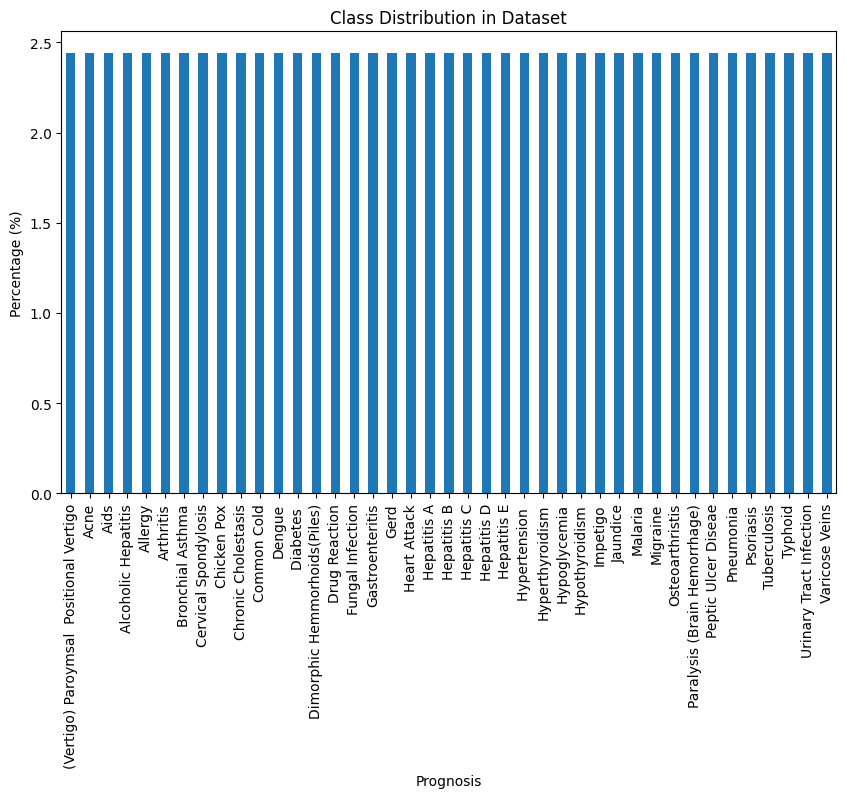

In [6]:
(100 * train_data.groupby('prognosis').size()/train_data.shape[0]).plot(x='prognosis', kind='bar', title='Class Distribution in Dataset', xlabel= "Prognosis", ylabel="Percentage (%)", figsize=(10,6))

The data appears to be balanced, with every prognosis appearing the same amount (approximately 2.4%).

### Distribution of Symptoms per Diagnosis

This step provides an insight on the prevalence of sympoms for each diagnosis within the dataset. It begins with a breakdown of the most common symptoms reported by patients in the dataset, displayed as a bar plot: 

<Axes: title={'center': 'Frequency Distribution of Symptoms Accross Progoses'}, xlabel='Total Occurrences', ylabel='Symptom'>

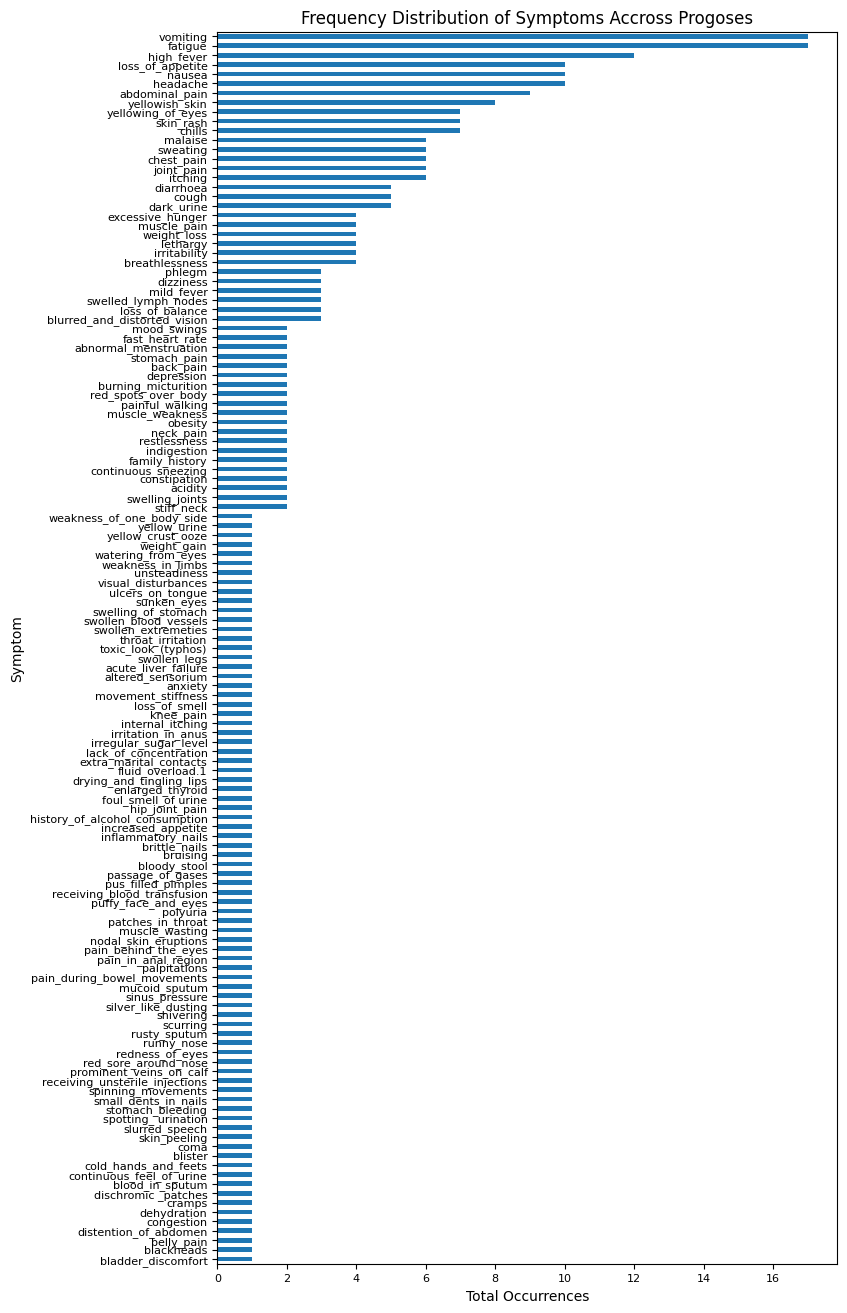

In [9]:
melted_train_data.reset_index().value_counts('variable').sort_values().plot(x='variable', kind= 'barh', figsize=(8, 16), title='Frequency Distribution of Symptoms Accross Progoses', xlabel='Total Occurrences', ylabel="Symptom", fontsize=8)

According to the plot above, the top five occurring symptoms include: 
1. Fatigue 
2. Vomiting 
3. High Fever
4. Nausea 
5. Headache 

Understanding the most prevalent features will be useful in feature selection and identifying which symptoms are worth exploring further. 

### Identifying Missing Symptoms 
Perhaps not every symptom included in the dataset appears for every disease. The code below performs a check to ensure we are not missing any symptoms before beginning to create the model. 

In [10]:
unique_sym = melted_train_data.reset_index()['variable'].unique().tolist()
set_unique = set(unique_sym)
set_symptoms = set(symptoms)
missing_symptoms = set_symptoms - set_unique
missing_symptoms_list = list(missing_symptoms)
print(missing_symptoms_list)

['fluid_overload']


The symptom fluid_overload does not seem to appear for any of the prognoses. Further inspection shows that there is an alternative column called fluid_overload.1 that houses the proper information for fluid overload symtpoms. As a result, this column will be dropped from the dataset. 

In [11]:
train_data = train_data.drop(labels='fluid_overload', axis='columns')

In [12]:
# Recalculating column length after removal.
total_columns = len(train_data.columns)
total_rows = len(train_data['prognosis'])
prognoses = train_data['prognosis'].unique().tolist()

print(f"The training dataset has a total of {total_rows} rows and {total_columns} columns. This means that there are {total_columns - 1} predictor variables. \nwithin the prognosis column, there are {len(prognoses)} diseases included.")

The training dataset has a total of 4920 rows and 132 columns. This means that there are 131 predictor variables. 
within the prognosis column, there are 41 diseases included.


The code below counts the occurrences of symptoms observed for each prognosis. The counts are displayed in plots.

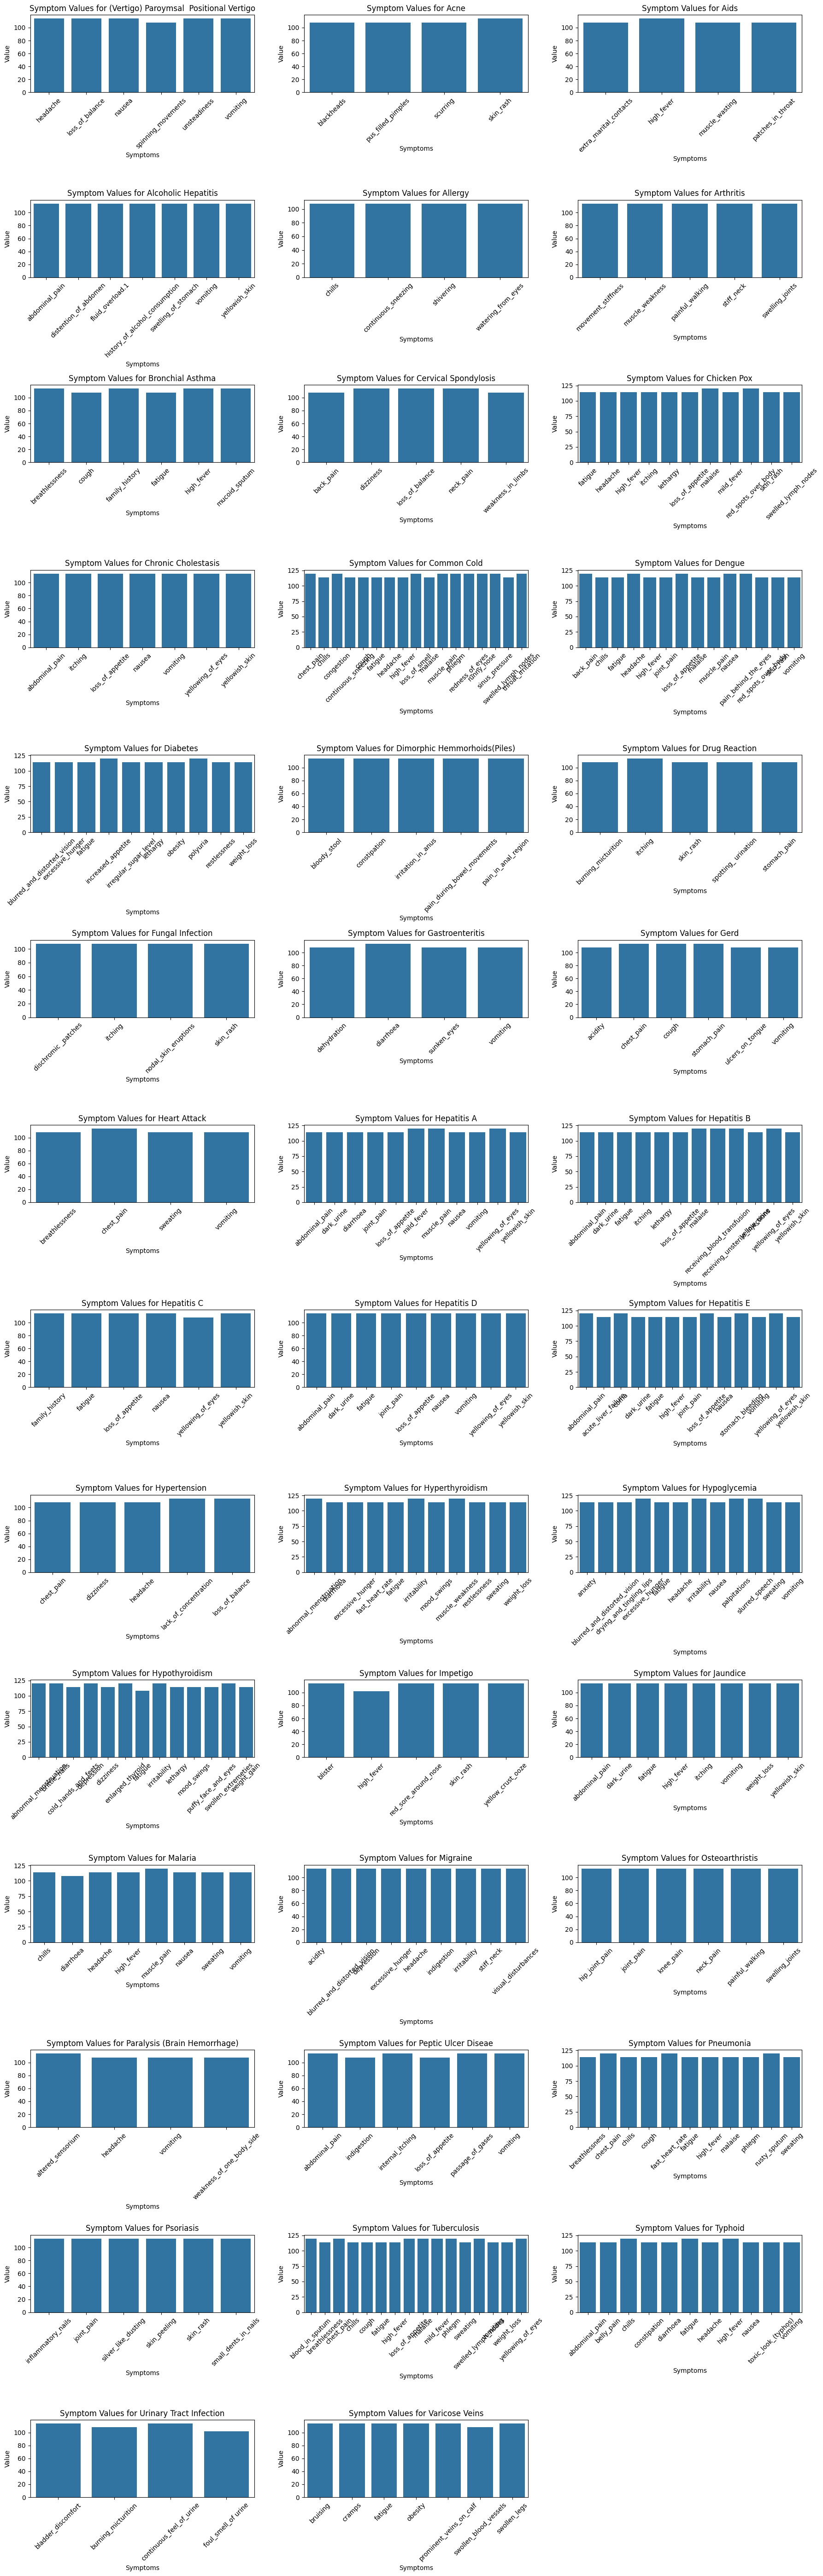

In [13]:
# Determine the number of prognosis categories
prognosis_list = melted_train_data.index.levels[0]
num_prognosis = len(prognosis_list)

# Set up the grid size (for example, 2 columns)
num_cols = 3
num_rows = (num_prognosis + num_cols - 1) // num_cols  # Calculate number of rows needed

# Create subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, num_rows * 4))
axes = axes.flatten()  # Flatten to easily index the axes

# Loop through each unique prognosis and create plots
for i, prognosis in enumerate(prognosis_list):
    # Filter the data for the current prognosis
    subset = melted_train_data.xs(prognosis)

    # Create the bar plot
    sns.barplot(x=subset.index, y=subset['value'], ax=axes[i])
    
    # Add titles and labels
    axes[i].set_title(f'Symptom Values for {prognosis}')
    axes[i].set_xlabel('Symptoms')
    axes[i].set_ylabel('Value')
    axes[i].tick_params(axis='x', rotation=45)

# Remove any empty subplots
for j in range(i + 1, num_rows * num_cols):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()
plt.show()

According to the plots above, the prognoses with the most symptoms reported include: 
1. Common Cold 
2. Tuberculosis 
3. Dengue 
4. Hypothyroidism 
5. Hepatitis E

Keeping track of the number of symptoms present for each disease can indicate a more complex condition, allow for potential prioritizing of the symptoms to be assessed in model generation. A correlation matrix between symptoms, outlining their relationship is displayed below: 

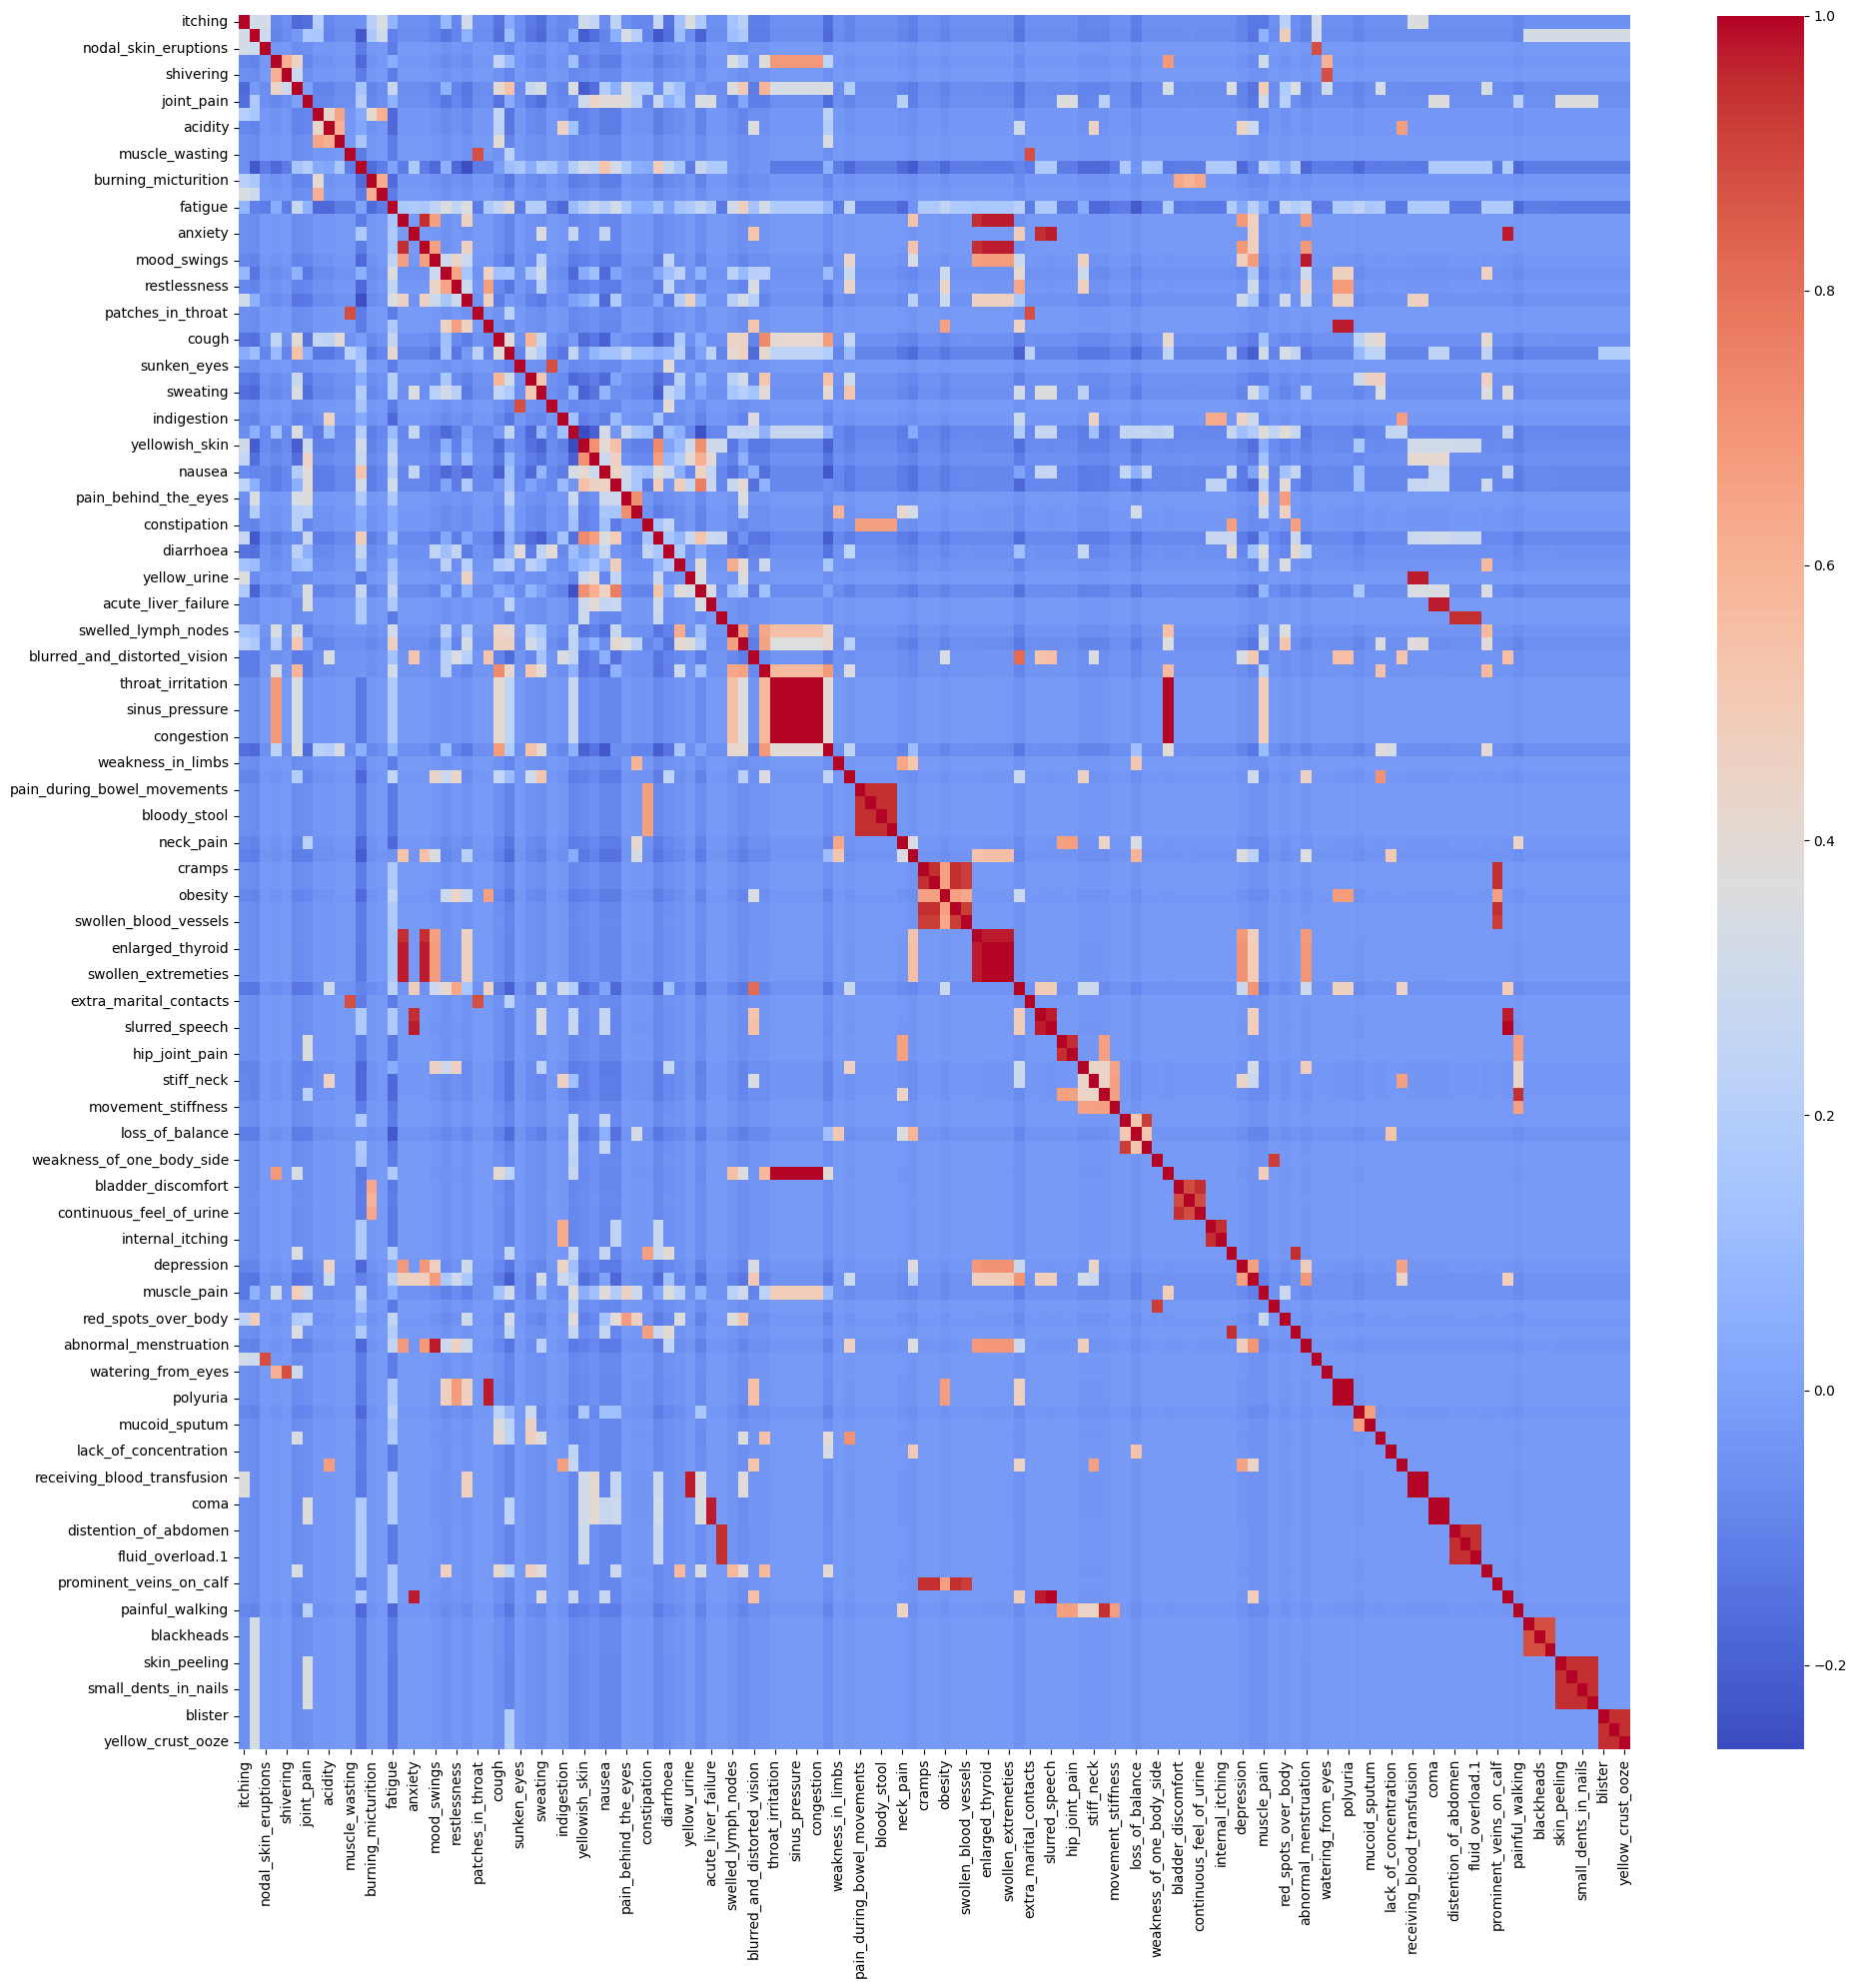

In [14]:
corr_matrix = train_data.corr(numeric_only=True)
plt.figure(figsize=(20,20))
sns.set_context(rc={"figure.figsize": (12,10)})
heat_plot = sns.heatmap(corr_matrix, annot=False, cmap=sns.color_palette("coolwarm", as_cmap=True))
plt.tight_layout()
plt.show()